In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from google.colab import files
uploaded = files.upload()

Saving supply_chain_data.csv to supply_chain_data.csv


In [2]:
df = pd.read_csv('supply_chain_data.csv')  # adjust filename to match what you uploaded
print(df.shape)
print(df.columns.tolist())
df.head()

(100, 24)
['Product type', 'SKU', 'Price', 'Availability', 'Number of products sold', 'Revenue generated', 'Customer demographics', 'Stock levels', 'Lead times', 'Order quantities', 'Shipping times', 'Shipping carriers', 'Shipping costs', 'Supplier name', 'Location', 'Lead time', 'Production volumes', 'Manufacturing lead time', 'Manufacturing costs', 'Inspection results', 'Defect rates', 'Transportation modes', 'Routes', 'Costs']


,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [3]:
print(df.isnull().sum())
print(df.dtypes)
df.describe()

Product type               0
SKU                        0
Price                      0
Availability               0
Number of products sold    0
Revenue generated          0
Customer demographics      0
Stock levels               0
Lead times                 0
Order quantities           0
Shipping times             0
Shipping carriers          0
Shipping costs             0
Supplier name              0
Location                   0
Lead time                  0
Production volumes         0
Manufacturing lead time    0
Manufacturing costs        0
Inspection results         0
Defect rates               0
Transportation modes       0
Routes                     0
Costs                      0
dtype: int64
Product type                object
SKU                         object
Price                      float64
Availability                 int64
Number of products sold      int64
Revenue generated          float64
Customer demographics       object
Stock levels                 int64
Lead times 

,Price,Availability,Number of products sold,Revenue generated,Stock levels,Lead times,Order quantities,Shipping times,Shipping costs,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Defect rates,Costs
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000
mean,49.462461,48.400000,460.990000,5776.048187,47.770000,15.960000,49.220000,5.750000,5.548149,17.080000,567.840000,14.77000,47.266693,2.277158,529.245782
std,31.168193,30.743317,303.780074,2732.841744,31.369372,8.785801,26.784429,2.724283,2.651376,8.846251,263.046861,8.91243,28.982841,1.461366,258.301696
min,1.699976,1.000000,8.000000,1061.618523,0.000000,1.000000,1.000000,1.000000,1.013487,1.000000,104.000000,1.00000,1.085069,0.018608,103.916248
25%,19.597823,22.750000,184.250000,2812.847151,16.750000,8.000000,26.000000,3.750000,3.540248,10.000000,352.000000,7.00000,22.983299,1.009650,318.778455
50%,51.239831,43.500000,392.500000,6006.352023,47.500000,17.000000,52.000000,6.000000,5.320534,18.000000,568.500000,14.00000,45.905622,2.141863,520.430444
75%,77.198228,75.000000,704.250000,8253.976921,73.000000,24.000000,71.250000,8.000000,7.601695,25.000000,797.000000,23.00000,68.621026,3.563995,763.078231
max,99.171329,100.000000,996.000000,9866.465458,100.000000,30.000000,96.000000,10.000000,9.929816,30.000000,985.000000,30.00000,99.466109,4.939255,997.413450


In [4]:
print(df['Supplier name'].nunique())  # adjust field name once confirmed
df['Supplier name'].value_counts()

5


,count
Supplier name,
Supplier 1,27
Supplier 2,22
Supplier 5,18
Supplier 4,18
Supplier 3,15


In [5]:
scorecard = df.groupby('Supplier name').agg(
    total_cost=('Costs', 'sum'),
    avg_manufacturing_cost=('Manufacturing costs', 'mean'),
    avg_defect_rate=('Defect rates', 'mean'),
    avg_lead_time=('Lead time', 'mean'),
    avg_shipping_cost=('Shipping costs', 'mean'),
    sku_count=('SKU', 'count'),
    total_revenue=('Revenue generated', 'sum')
).round(2)

scorecard['cost_share_pct'] = (scorecard['total_cost'] / scorecard['total_cost'].sum() * 100).round(1)
scorecard = scorecard.sort_values('total_cost', ascending=False)
scorecard

,total_cost,avg_manufacturing_cost,avg_defect_rate,avg_lead_time,avg_shipping_cost,sku_count,total_revenue,cost_share_pct
Supplier name,,,,,,,,
Supplier 1,15520.98,45.25,1.80,14.78,5.51,27,157529.00,29.3
Supplier 2,11330.60,41.62,2.36,18.55,5.74,22,125467.42,21.4
Supplier 5,9648.41,44.77,2.67,18.06,5.79,18,110343.46,18.2
Supplier 4,9392.59,62.71,2.34,15.22,5.76,18,86468.96,17.7
Supplier 3,7032.00,43.63,2.47,20.13,4.79,15,97795.98,13.3


In [6]:
scorecard['defect_rank'] = scorecard['avg_defect_rate'].rank(ascending=False)
scorecard['cost_rank'] = scorecard['total_cost'].rank(ascending=False)

# Flag suppliers that are high-spend AND high-defect — the actual risk case
risk_flag = scorecard[(scorecard['cost_rank'] <= 2) & (scorecard['defect_rank'] <= 2)]
print("High-spend, high-defect suppliers (concentration risk):")
print(risk_flag)

High-spend, high-defect suppliers (concentration risk):
Empty DataFrame
Columns: [total_cost, avg_manufacturing_cost, avg_defect_rate, avg_lead_time, avg_shipping_cost, sku_count, total_revenue, cost_share_pct, defect_rank, cost_rank]
Index: []


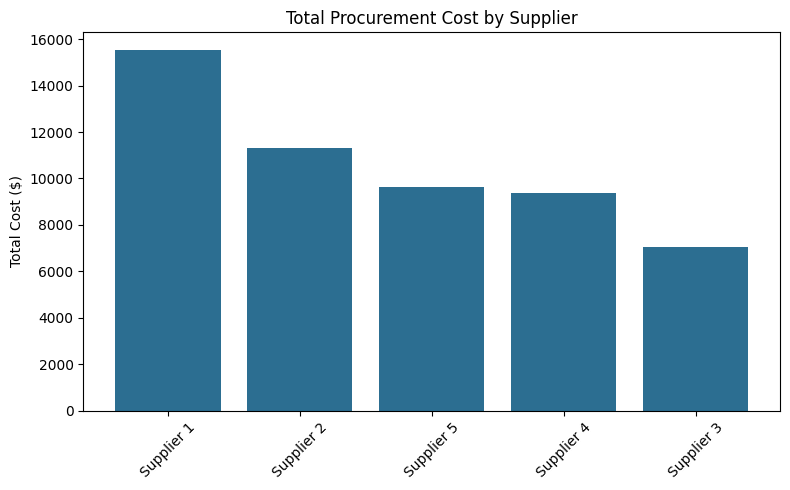

In [7]:
plt.figure(figsize=(8,5))
plt.bar(scorecard.index, scorecard['total_cost'], color='#2C6E91')
plt.ylabel('Total Cost ($)')
plt.title('Total Procurement Cost by Supplier')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('cost_by_supplier.png', dpi=150)
plt.show()

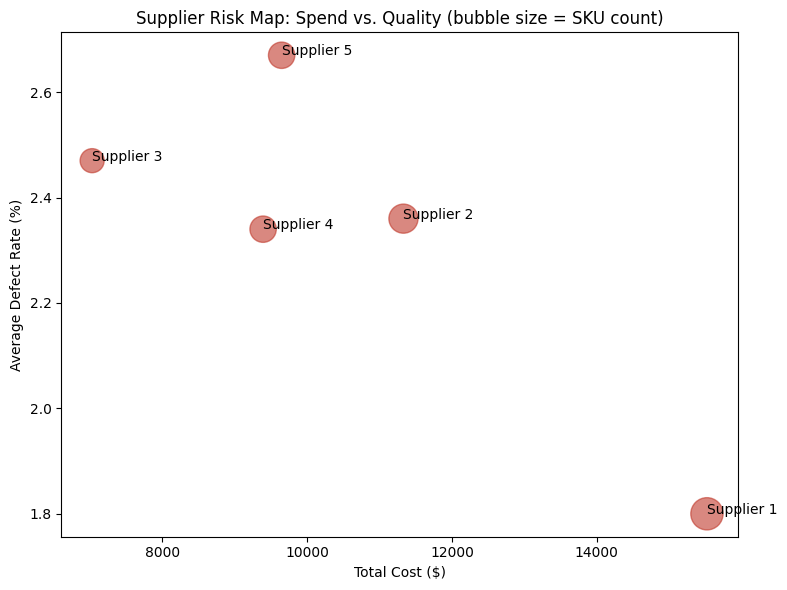

In [8]:
plt.figure(figsize=(8,6))
plt.scatter(scorecard['total_cost'], scorecard['avg_defect_rate'],
            s=scorecard['sku_count']*20, alpha=0.6, color='#C0392B')
for supplier in scorecard.index:
    plt.annotate(supplier, (scorecard.loc[supplier,'total_cost'], scorecard.loc[supplier,'avg_defect_rate']))
plt.xlabel('Total Cost ($)')
plt.ylabel('Average Defect Rate (%)')
plt.title('Supplier Risk Map: Spend vs. Quality (bubble size = SKU count)')
plt.tight_layout()
plt.savefig('supplier_risk_map.png', dpi=150)
plt.show()

In [9]:
insight = """
Supplier Performance Analysis — Key Finding

Supplier 1 accounts for 29.3% of total procurement cost, the largest share among
five suppliers, yet delivers the lowest defect rate (1.80%) and fastest average
lead time (14.78 days) in the portfolio. This indicates the spend concentration
is performance-justified rather than a risk exposure.

Conversely, Supplier 5 combines a mid-tier cost share (18.2%) with the highest
defect rate (2.67%) and a below-average lead time (18.06 days) — a mismatch
between cost and performance that warrants a supplier review or renegotiation
of quality terms.

Recommendation: Maintain or grow allocation to Supplier 1; open a performance
conversation with Supplier 5 before renewing terms.
"""
print(insight)


Supplier Performance Analysis — Key Finding

Supplier 1 accounts for 29.3% of total procurement cost, the largest share among 
five suppliers, yet delivers the lowest defect rate (1.80%) and fastest average 
lead time (14.78 days) in the portfolio. This indicates the spend concentration 
is performance-justified rather than a risk exposure.

Conversely, Supplier 5 combines a mid-tier cost share (18.2%) with the highest 
defect rate (2.67%) and a below-average lead time (18.06 days) — a mismatch 
between cost and performance that warrants a supplier review or renegotiation 
of quality terms.

Recommendation: Maintain or grow allocation to Supplier 1; open a performance 
conversation with Supplier 5 before renewing terms.



In [10]:
scorecard.to_csv('supplier_scorecard.csv')
from google.colab import files
files.download('supplier_scorecard.csv')
files.download('cost_by_supplier.png')
files.download('supplier_risk_map.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>